# Adversarial Patch Experiments — YOLOv8 / YOLO11 / YOLO26

**Capstone: Person-Vanishing Adversarial Patch Attack against Ultralytics YOLO**

Trains patches directly against each model on a **common 14-image manifest** (images where all three models detect ≥1 person), then runs cross-version transfer tests.

**Before running:** `Runtime > Change runtime type > T4 GPU`

## 1. Setup

In [13]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')

CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [14]:
REPO_URL = 'https://github.com/Cmaddock99/Patch_Yolo.git'
REPO_DIR = '/content/Adversarial_Patch'
import os
if os.path.isdir(REPO_DIR):
    print('Repo exists — pulling latest ...')
    !git -C {REPO_DIR} pull
else:
    !git clone {REPO_URL} {REPO_DIR}
%cd {REPO_DIR}

Repo exists — pulling latest ...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 429 bytes | 429.00 KiB/s, done.
From https://github.com/Cmaddock99/Patch_Yolo
   fdf3d80..782cafb  main       -> origin/main
Updating fdf3d80..782cafb
Fast-forward
 experiments/colab_run.ipynb | 7 -------
 1 file changed, 7 deletions(-)
/content/Adversarial_Patch


In [15]:
# Mount Google Drive and copy yolo26n.pt (not tracked in git — *.pt is gitignored)
from google.colab import drive
drive.mount('/content/drive')
import shutil, os
src = '/content/drive/MyDrive/yolo26n.pt'
dst = '/content/Adversarial_Patch/yolo26n.pt'
if os.path.exists(src):
    shutil.copy(src, dst)
    print(f'Copied yolo26n.pt ({os.path.getsize(dst):,} bytes)')
else:
    raise FileNotFoundError(f'yolo26n.pt not found on Drive at {src} — upload it first')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied yolo26n.pt (5,544,453 bytes)


In [16]:
!pip install ultralytics opencv-python-headless tqdm -q

## 2. Manifest — Common 14-Image Subset

Finds images detected as 'person' by **all three** models simultaneously. This ensures fair cross-version comparisons on a fixed evaluation set.

In [17]:
!python experiments/build_intersection_manifest.py

Found 48 images in data/custom_images

Running yolov8n ...
  Done.

Running yolo11n ...
  Done.

Running yolo26n ...
  Done.

Image                                           yolov8n   yolo11n   yolo26n  IN SET
-----------------------------------------------------------------------------------
IMG_20260410_114600819_HDR.jpg                        1         1         1     YES
IMG_20260410_114610856_HDR.jpg                        1         1         1     YES
IMG_20260410_114612607_HDR.jpg                        1         1         1     YES
IMG_20260410_114647615_HDR.jpg                        2         2         2     YES
IMG_20260410_114651471_HDR.jpg                        2         2         2     YES
IMG_20260410_114652438_HDR.jpg                        2         2         2     YES
IMG_20260410_114704977_HDR.jpg                        1         1         1     YES
IMG_20260410_114705844_HDR.jpg                        1         1         1     YES
IMG_20260410_114711669_HDR.jpg    

## 3. Forward Contract Diagnostic — YOLO26

Confirms the YOLO26 inner model output shape and that `one2many['scores']` has a `grad_fn` (gradient flows through it). Run once before training.

In [18]:
import torch
from ultralytics import YOLO

yolo26 = YOLO('yolo26n.pt')
inner26 = yolo26.model.eval()
dummy = torch.zeros(1, 3, 640, 640)
with torch.enable_grad():
    out = inner26(dummy)
print('type(out):', type(out))
if isinstance(out, (list, tuple)):
    print('len(out):', len(out))
    print('out[0].shape:', out[0].shape)
    if isinstance(out[1], dict):
        for k, v in out[1].items():
            print(f"preds['{k}'] keys:", list(v.keys()))
            for kk, vv in v.items():
                if isinstance(vv, torch.Tensor):
                    print(f'  [{kk}] shape={vv.shape}, grad_fn={vv.grad_fn}')
del yolo26, inner26  # free VRAM before training

type(out): <class 'tuple'>
len(out): 2
out[0].shape: torch.Size([1, 300, 6])
preds['one2many'] keys: ['boxes', 'scores', 'feats']
  [boxes] shape=torch.Size([1, 4, 8400]), grad_fn=None
  [scores] shape=torch.Size([1, 80, 8400]), grad_fn=None
preds['one2one'] keys: ['boxes', 'scores', 'feats']
  [boxes] shape=torch.Size([1, 4, 8400]), grad_fn=None
  [scores] shape=torch.Size([1, 80, 8400]), grad_fn=None


## 4. Direct Training — YOLOv8n

In [19]:
!python experiments/ultralytics_patch.py \
    --model yolov8n \
    --manifest data/manifests/common_14.txt \
    --seed 42 \
    --epochs 1000 \
    --lr 0.01 \
    --tv-weight 0.05 \
    --nps-weight 0.01 \
    --block-erase-prob 0.5 \
    --cutout-prob 0.3 \
    --rot-max 15.0 \
    --patch-size 100 \
    --batch-size 8 \
    --display 5 \
    --resume

Device: cuda
Model:  yolov8n  (end2end=no)

Loading images from manifest data/manifests/common_14.txt ...
  Loaded 48 images.

Loading yolov8n ...

Running clean inference to select training images ...
  Selected 18/48 images with person detections.

Resumed from checkpoint at epoch 1000 (continuing from epoch 1001)
Training: 0it [00:00, ?it/s]

Patch saved → outputs/yolov8n_patch_v2/patches/patch.png

Evaluating attack effectiveness ...

  Model              : yolov8n
  Training images    : 18
  Epochs             : 1000
  Final det loss     : 0.5510  (↓ = more effective)
  Person dets BEFORE : 20  (mean conf 0.589)
  Person dets AFTER  : 1  (mean conf 0.552)
  Detection suppression: 95.0%
  Output dir         : outputs/yolov8n_patch_v2/


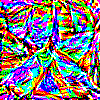

{
  "model": "yolov8n",
  "co_model": null,
  "epochs": 1000,
  "training_images": 18,
  "subset_size": 18,
  "patch_size": 100,
  "final_det_loss": 0.55105,
  "clean_person_detections": 20,
  "patched_person_detections": 1,
  "detection_suppression_pct": 95.0,
  "mean_conf_clean": 0.5893,
  "mean_conf_patched": 0.5517,
  "loss_source": "channel4",
  "score_tensor_shape": null,
  "head_end2end": false,
  "lr": 0.01,
  "tv_weight": 0.05,
  "nps_weight": 0.01,
  "block_erase_prob": 0.5,
  "cutout_prob": 0.3,
  "cutout_size": 20,
  "rot_max": 15.0,
  "grad_clip": 0.0,
  "checkpoint_interval": 100,
  "resumed": true,
  "device": "cuda"
}


In [20]:
from IPython.display import Image as IPImage, display
import json
display(IPImage('outputs/yolov8n_patch_v2/patches/patch.png', width=200))
with open('outputs/yolov8n_patch_v2/results.json') as f:
    print(json.dumps(json.load(f), indent=2))

## 5. Direct Training — YOLO11n

In [21]:
!python experiments/ultralytics_patch.py \
    --model yolo11n \
    --manifest data/manifests/common_14.txt \
    --seed 42 \
    --epochs 1000 \
    --lr 0.01 \
    --tv-weight 0.05 \
    --nps-weight 0.01 \
    --block-erase-prob 0.5 \
    --cutout-prob 0.3 \
    --rot-max 15.0 \
    --patch-size 100 \
    --batch-size 8 \
    --display 5 \
    --resume

Device: cuda
Model:  yolo11n  (end2end=no)

Loading images from manifest data/manifests/common_14.txt ...
  Loaded 48 images.

Loading yolo11n ...

Running clean inference to select training images ...
  Selected 33/48 images with person detections.

Resumed from checkpoint at epoch 1000 (continuing from epoch 1001)
Training: 0it [00:00, ?it/s]

Patch saved → outputs/yolo11n_patch_v2/patches/patch.png

Evaluating attack effectiveness ...

  Model              : yolo11n
  Training images    : 33
  Epochs             : 1000
  Final det loss     : 0.5925  (↓ = more effective)
  Person dets BEFORE : 33  (mean conf 0.683)
  Person dets AFTER  : 10  (mean conf 0.645)
  Detection suppression: 69.7%
  Output dir         : outputs/yolo11n_patch_v2/


In [22]:
import json
with open('outputs/yolo11n_patch_v2/results.json') as f:
    print(json.dumps(json.load(f), indent=2))

{
  "model": "yolo11n",
  "co_model": null,
  "epochs": 1000,
  "training_images": 33,
  "subset_size": 33,
  "patch_size": 100,
  "final_det_loss": 0.59249,
  "clean_person_detections": 33,
  "patched_person_detections": 10,
  "detection_suppression_pct": 69.7,
  "mean_conf_clean": 0.6829,
  "mean_conf_patched": 0.6451,
  "loss_source": "channel4",
  "score_tensor_shape": null,
  "head_end2end": false,
  "lr": 0.01,
  "tv_weight": 0.05,
  "nps_weight": 0.01,
  "block_erase_prob": 0.5,
  "cutout_prob": 0.3,
  "cutout_size": 20,
  "rot_max": 15.0,
  "grad_clip": 0.0,
  "checkpoint_interval": 100,
  "resumed": true,
  "device": "cuda"
}


## 6. Direct Training — YOLO26n

Root cause of v1 failure: `end2end=True` returns `(B, 300, 6)` as `out[0]`. Fixed to use `preds['one2many']['scores']` `(B, 80, 8400)` which retains gradient flow.

**LR note:** Using `--lr 0.001` (10× lower than v8/v11). The one2many gradient landscape has a different scale than v8/v11 class scores — a lower learning rate prevents the patch from diverging early.

In [23]:
import ultralytics
print('Ultralytics version:', ultralytics.__version__)
from ultralytics import YOLO
try:
    m = YOLO('yolo26n.pt')
    print('yolo26n loaded OK')
except Exception as e:
    print('Error:', e)

Ultralytics version: 8.4.37
yolo26n loaded OK


In [ ]:
!python experiments/ultralytics_patch.py \
    --model yolo26n \
    --manifest data/manifests/common_14.txt \
    --seed 42 \
    --epochs 1000 \
    --lr 0.001 \
    --tv-weight 0.05 \
    --nps-weight 0.01 \
    --block-erase-prob 0.5 \
    --cutout-prob 0.3 \
    --rot-max 15.0 \
    --patch-size 100 \
    --batch-size 8 \
    --display 5 \
    --resume

Device: cuda
Model:  yolo26n  (end2end=yes)

Loading images from manifest data/manifests/common_14.txt ...
  Loaded 48 images.

Loading yolo26n ...

Running clean inference to select training images ...
  Selected 43/48 images with person detections.
  [v26] Restored cv2/cv3 from one2one_cv2/cv3 (fuse() had cleared them); one2many head is now live and differentiable

Training for 1000 epochs ...
  Epoch    1/1000 — det_loss: 0.0856
  Epoch   50/1000 — det_loss: 0.0883
  Epoch  100/1000 — det_loss: 0.0985
  Epoch  150/1000 — det_loss: 0.0934
  Epoch  200/1000 — det_loss: 0.0907
  Epoch  250/1000 — det_loss: 0.0902
  Epoch  300/1000 — det_loss: 0.0780
  Epoch  350/1000 — det_loss: 0.0857
  Epoch  400/1000 — det_loss: 0.0824
Training:  43% 433/1000 [01:44<02:50,  3.33it/s]

In [ ]:
import json
with open('outputs/yolo26n_patch_v2/results.json') as f:
    print(json.dumps(json.load(f), indent=2))

## 7. Cross-Version Transfer Tests

Patch trained on YOLOv8n — evaluated against YOLO11n and YOLO26n. Uses the same common manifest for a fair comparison.

Output dirs: `yolo11n_from_yolov8n_patch_v2_transfer/`, etc.

In [ ]:
# v8 patch → v11
!python experiments/ultralytics_patch.py \
    --model yolo11n --eval-only \
    --load-patch outputs/yolov8n_patch_v2/patches/patch.png \
    --manifest data/manifests/common_14.txt \
    --display 3

In [ ]:
# v8 patch → v26
!python experiments/ultralytics_patch.py \
    --model yolo26n --eval-only \
    --load-patch outputs/yolov8n_patch_v2/patches/patch.png \
    --manifest data/manifests/common_14.txt \
    --display 3

In [ ]:
# v11 patch → v26
!python experiments/ultralytics_patch.py \
    --model yolo26n --eval-only \
    --load-patch outputs/yolo11n_patch_v2/patches/patch.png \
    --manifest data/manifests/common_14.txt \
    --display 3

## 10. Multi-Model Joint Training — YOLOv8n + YOLO11n

Trains a **single patch** that minimises detection loss on both YOLOv8n and YOLO11n simultaneously (losses averaged each step). Literature basis: DOEPatch (Tan 2024), T-SEA (Huang 2022) ensemble approach.

Hypothesis: a jointly-trained patch should transfer better to YOLO26n than a single-model patch because it has seen a broader gradient landscape during training.

In [ ]:
!python experiments/ultralytics_patch.py \
    --model yolov8n \
    --co-model yolo11n \
    --manifest data/manifests/common_14.txt \
    --seed 42 \
    --epochs 1000 \
    --lr 0.01 \
    --tv-weight 0.05 \
    --nps-weight 0.01 \
    --block-erase-prob 0.5 \
    --cutout-prob 0.3 \
    --rot-max 15.0 \
    --patch-size 100 \
    --batch-size 8 \
    --display 5 \
    --resume
# Output: outputs/yolov8n+yolo11n_joint_patch_v2/

In [ ]:
from IPython.display import Image as IPImage, display
import json
display(IPImage('outputs/yolov8n+yolo11n_joint_patch_v2/patches/patch.png', width=200))
with open('outputs/yolov8n+yolo11n_joint_patch_v2/results.json') as f:
    print(json.dumps(json.load(f), indent=2))

## 11. Cross-Version Transfer — Joint Patch → All Models

Evaluate the jointly-trained patch (v8n+v11n) on each target model. Compare transfer rates against the single-model v8n baseline from Section 7.

In [ ]:
# Joint patch → v8n (self-eval on primary model)
!python experiments/ultralytics_patch.py \
    --model yolov8n --eval-only \
    --load-patch outputs/yolov8n+yolo11n_joint_patch_v2/patches/patch.png \
    --manifest data/manifests/common_14.txt \
    --display 3

In [ ]:
# Joint patch → v11n (co-model self-eval)
!python experiments/ultralytics_patch.py \
    --model yolo11n --eval-only \
    --load-patch outputs/yolov8n+yolo11n_joint_patch_v2/patches/patch.png \
    --manifest data/manifests/common_14.txt \
    --display 3

In [ ]:
# Joint patch → v26n (key transfer test)
!python experiments/ultralytics_patch.py \
    --model yolo26n --eval-only \
    --load-patch outputs/yolov8n+yolo11n_joint_patch_v2/patches/patch.png \
    --manifest data/manifests/common_14.txt \
    --display 3

## 8. Results Summary

In [ ]:
import json, os
print(f"{'Experiment':<55} {'Clean':>6} {'Patched':>8} {'Suppression':>12}")
print('-' * 83)
for run_dir in sorted(os.listdir('outputs')):
    rp = f'outputs/{run_dir}/results.json'
    if os.path.exists(rp):
        with open(rp) as f:
            r = json.load(f)
        tag = ' [TRANSFER]' if 'transfer' in run_dir else ' [DIRECT]  '
        label = run_dir + tag
        print(f"{label:<55} {r.get('clean_person_detections','-'):>6} "
              f"{r.get('patched_person_detections','-'):>8} "
              f"{str(r.get('detection_suppression_pct','-'))+'%':>12}")

## 9. Push Results to GitHub

In [ ]:
from google.colab import userdata
import subprocess

TOKEN = userdata.get('GITHUB_PAT')  # set this in Colab Secrets (key icon in left sidebar)
REPO  = 'Cmaddock99/Patch_Yolo'

!git config user.email 'cmaddock99@gmail.com'
!git config user.name 'Cmaddock99'
!git add outputs/ experiments/ data/manifests/
!git commit -m 'Add v2 results: robustness improvements (DePatch+T-SEA+EoT) + joint training'
subprocess.run(['git', 'remote', 'set-url', 'origin',
                f'https://{TOKEN}@github.com/{REPO}.git'], check=True)
!git push
